In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df_p = pd.read_csv("Products.csv", sep=";")
df_c = pd.read_csv("Customers.csv", sep=';')
df_od = pd.read_csv("Order_details.csv", sep=";")
df_o = pd.read_csv("Orders.csv", sep=";")
df_e = pd.read_excel("Employees.xlsx")

In [3]:
df_o['OrderDate']= df_o['OrderDate'].astype('datetime64[ns]')
df_od['Revenue'] = df_od['UnitPrice']*df_od['Quantity']*(1-df_od['Discount'])
df_o.isnull().sum()

OrderID          0
CustomerID       0
EmployeeID       0
OrderDate        0
RequiredDate     0
ShippedDate     21
Freight          0
dtype: int64

## 1. Подготовка данных

- Загружены 5 файлов: Customers, Orders, Order_details, Products, Employees.
- Поле `OrderDate` приведено к типу `datetime`.
- В `Order_details` создан столбец `Revenue = UnitPrice * Quantity * (1 - Discount)`.
- Проверены пропуски: только `ShippedDate` содержит 21 NULL (неотправленные заказы) — они оставлены без изменений.

In [93]:
Total_revenue = df_od['Revenue'].sum()
df_o["YearMonth"] = df_o["OrderDate"].dt.to_period('M')
df_ood = df_o.merge(df_od, on = "OrderID", how="inner")
Month_revenue = df_ood.groupby(['YearMonth']).Revenue.sum().reset_index()

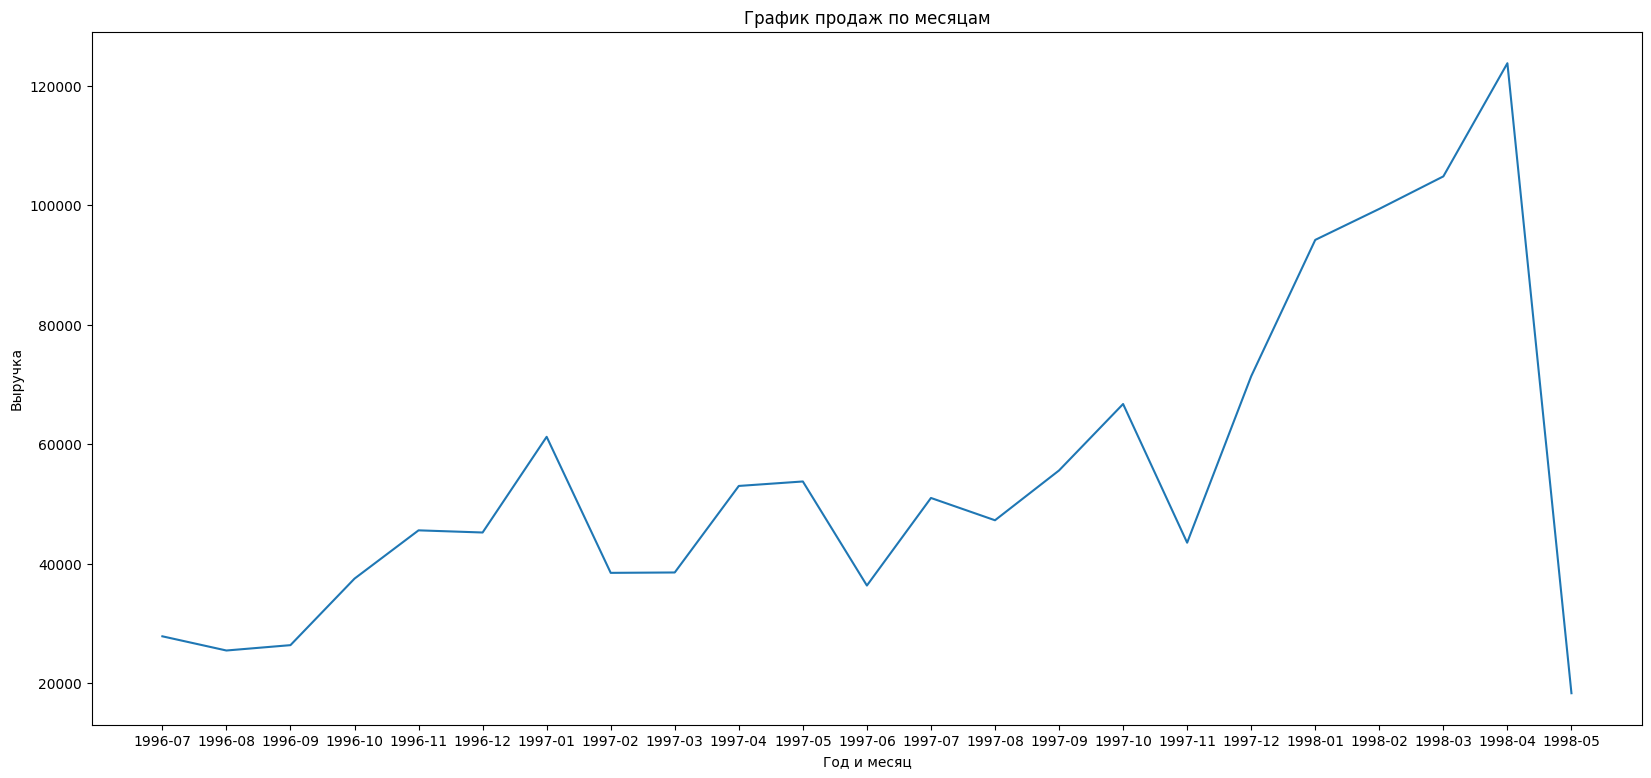

In [94]:
plt.figure(figsize=(20, 9))
plt.plot(Month_revenue['YearMonth'].astype(str), Month_revenue['Revenue'])
plt.xlabel('Год и месяц'), plt.ylabel('Выручка'), plt.title('График продаж по месяцам')
plt.show()

## 2. Помесячная динамика выручки

- Вычислена общая выручка за весь период.
- Создан столбец `YearMonth` (формат `Period`) на основе `OrderDate`.
- Данные объединены (`merge`) и сгруппированы по месяцам.
- Построен линейный график.

**Вывод:** Выручка имеет сезонные колебания, пик приходится на декабрь 1997 года. Обрыв в конце графика связан с неполными данными за последний месяц.

In [108]:
df_odp = df_od.merge (df_p, on = 'ProductID', how = 'inner')
Top_products = df_odp.groupby('ProductName').agg({'Revenue':'sum'}).reset_index().sort_values("Revenue", ascending = False).head(10)
Top_categorys = df_odp.groupby('CategoryName').agg({'Revenue':'sum'}).reset_index().sort_values("Revenue", ascending = False).head(5)

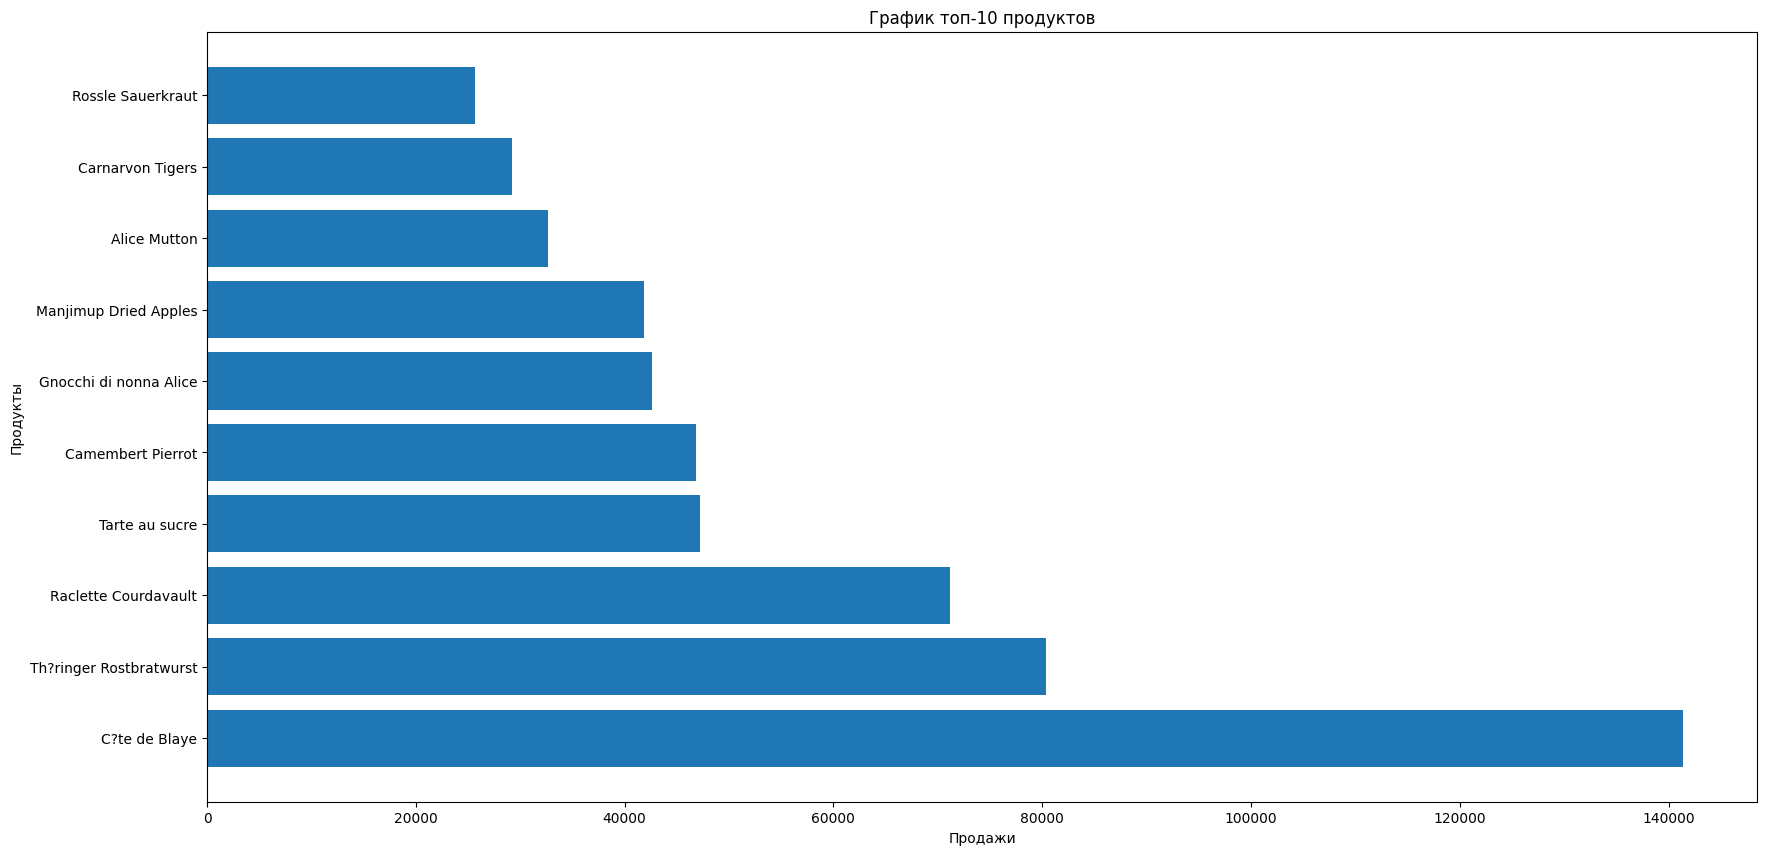

In [97]:
plt.figure(figsize=(20, 10))
plt.barh(Top_products['ProductName'], Top_products['Revenue'])
plt.xlabel('Продажи'), plt.ylabel('Продукты'), plt.title('График топ-10 продуктов')
plt.show()

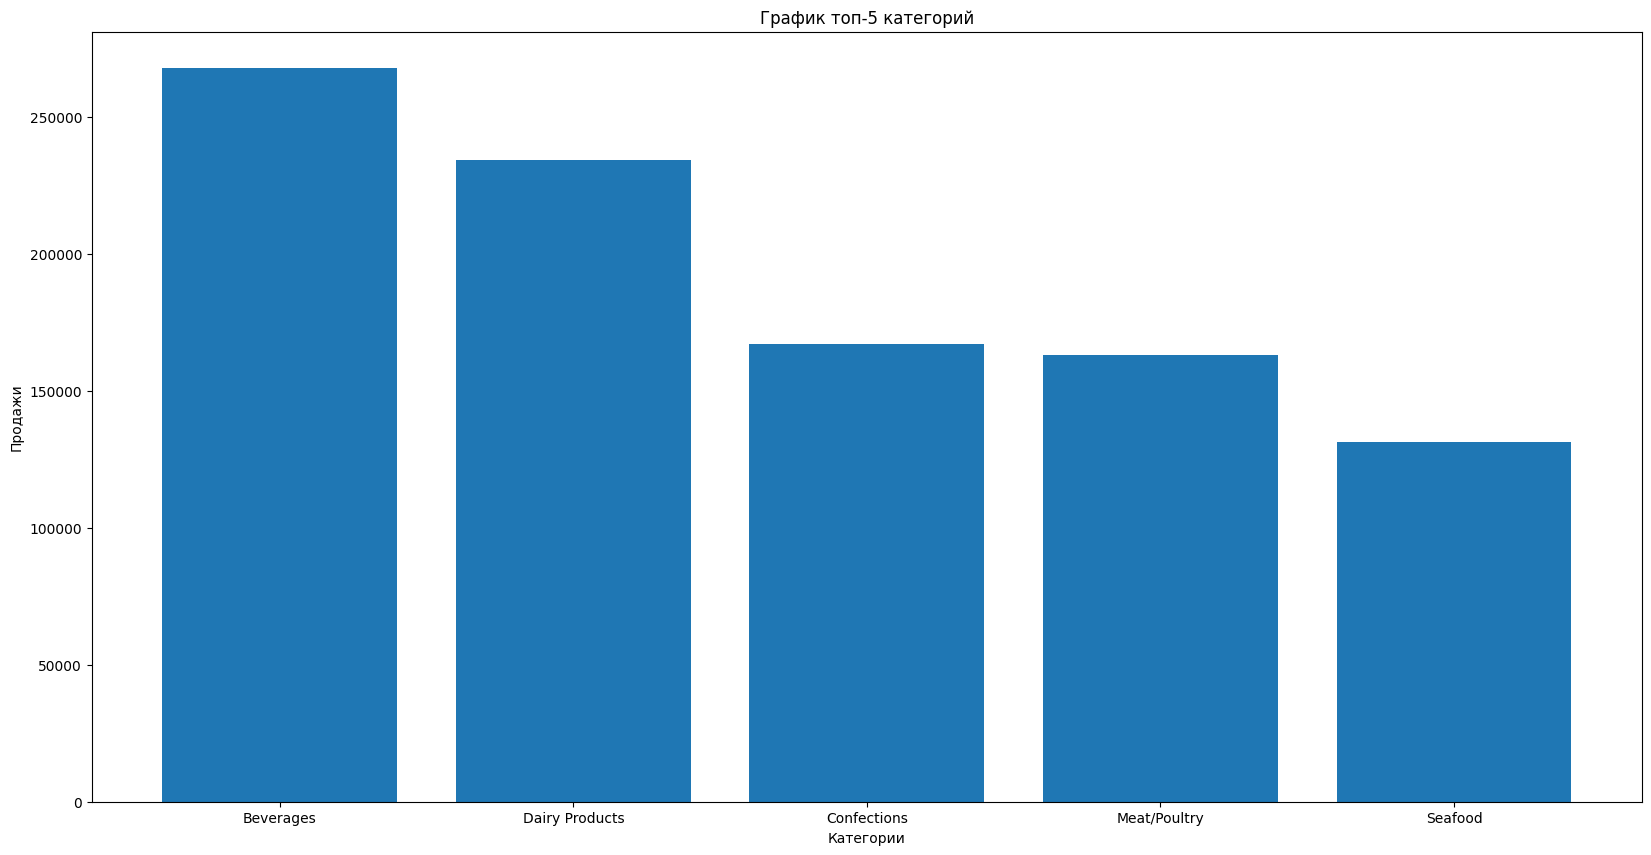

In [107]:
plt.figure(figsize=(20, 10))
plt.bar(Top_categorys['CategoryName'], Top_categorys['Revenue'])
plt.xlabel('Категории'), plt.ylabel('Продажи'), plt.title('График топ-5 категорий')
plt.show()

## 3. Топ товаров и категорий

- Объединены таблицы `Order_details` и `Products`.
- Рассчитана суммарная выручка по каждому продукту и каждой категории.
- Отобраны топ-10 продуктов и топ-5 категорий.
- Построены горизонтальная (для продуктов) и вертикальная (для категорий) столбчатые диаграммы.

**Выводы:**
- **Топ-1 продукт:** «Côte de Blaye» (высокая цена + хорошие продажи).
- **Топ-1 категория:** «Beverages» (напитки) — лидер по выручке.